<a href="https://colab.research.google.com/github/BinaryGivens/A4/blob/main/A4_Vector_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 789 — Assignment 4: What Actually Moves RAG Accuracy?
**AI-Powered Cyber Attacks and Defenses · Fall 2026 · UNLV · Prof. Yoohwan Kim**

One security corpus, one question set, one scorer — and you change **one knob at a time**:

| Part | Knob you turn | Measured by |
|---|---|---|
| A | chunking: **fixed (non-recursive) vs. recursive**, chunk size 200 → 3200 chars | recall@5 |
| B | retrieval: **BM25 vs. dense vs. hybrid**, and the BM25 tokenizer | recall@5 / @10 |
| C | **embedding model** (MiniLM, bge, nomic, ATTACK-BERT) | recall@5 + speed |
| D | vector store: **ChromaDB (LlamaIndex) vs. Pinecone (LangChain)**, and **TurboQuant** vector compression | recall, agreement, bytes |
| E | the LLM answers: naive RAG vs. your best RAG vs. whole corpus in context, and **TurboQuant KV-cache** | answer accuracy |

**The corpus** — 35 documents (~18k words) from the fictional company *Vandelay Industries*: incident
tickets, EDR/IDS exports, asset inventory (two revisions), IAM groups, HR records, CVE write-ups, threat
intel. **The questions** — 26, in six types: `single_hop`, `multi_hop` (3–4 documents must be joined),
`aggregation` (the answer is written nowhere, it must be counted), `temporal`, `negation` (the honest
answer is "not in the corpus") and `lexical` (opaque identifiers such as `CVE-2026-3117` vs. `CVE-2026-3171`).

**How you work.** You *build* the pipelines with an AI assistant in your browser (Claude in Chrome,
Gemini in Chrome, or Gemini in Colab) — every 🛠️ cell has a prompt to start from. You *measure* with the
fixed harness `cs789rag.py` (do not edit it). You *think* in the ✍️ cells — that part is yours alone.

> Runtime: **Colab Pro, GPU = L4** (A100 also fine). Your own PC with an NVIDIA GPU ≥ 16 GB also works: run `./start.sh`.

---
## Part 0 — Setup (≈ 15 min)

**0.1** `Runtime → Change runtime type → L4 GPU → Save`. Then run the next cell. It downloads the
assignment files, installs the Python packages, and **starts installing vLLM in the background**
(the LLM server for Part E) so you do not wait for it later.

In [1]:
# 0.1 Get the files, install packages, start the vLLM install in the background  (~2 min)
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("/content/A4"):
        !git clone -q https://github.com/unlv-cs789-f26/A4.git /content/A4
    %cd /content/A4
    !pip -q install -r requirements.txt
    # vLLM goes into its own virtualenv so it cannot break this notebook's PyTorch.
    vllm_install = subprocess.Popen("bash install_vllm.sh > /content/vllm_install.log 2>&1", shell=True)
sys.path.insert(0, os.getcwd())
import cs789rag as H
H.gpu()
docs = H.load_corpus()
QUESTIONS = H.load_questions()
print(len(docs), "documents,", sum(len(d.text) for d in docs), "characters;", len(QUESTIONS), "questions")

/content/A4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.8/832.8 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.8/572.8 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.6/173.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

**0.2 Look at the data before you touch it.** Run the cell, then open two documents in the file
browser (📁 on the left → `A4/corpus/`): `asset_inventory_v2.md` and `inc_2026_041.md`.

In [2]:
import pandas as pd
pd.set_option("display.max_colwidth", 120)
display(pd.DataFrame([{"doc_id": d.doc_id, "type": d.doc_type, "date": d.date, "status": d.status,
                       "chars": len(d.text), "title": d.title} for d in docs]))
display(pd.DataFrame(QUESTIONS)[["id", "type", "hops", "question", "gold_answer"]])

,doc_id,type,date,status,chars,title
0,access-review-q1,iam,2026-02-20,current,3919,Q1 2026 Privileged Access Review
1,advisory-aperture-sa-2026-014,advisory,2026-02-14,current,3083,Vendor Advisory APERTURE-SA-2026-014
2,advisory-kestrel-sa-2026-007,advisory,2026-03-04,current,2844,Vendor Advisory KESTREL-SA-2026-007
3,asset-inventory-v1,inventory,2026-02-10,outdated,3432,Vandelay Industries Asset Inventory (Revision 1)
4,asset-inventory-v2,inventory,2026-03-16,current,3480,"Vandelay Industries Asset Inventory (Revision 2, current)"
5,auth-log-20260314,log,2026-03-14,current,3085,Authentication Log Excerpt - 2026-03-14
6,change-log-march,change,2026-03-27,current,3067,Change Management Log - March 2026
7,chg-2026-0884,change,2026-03-03,current,2910,"CHG-2026-0884 - Contractor Offboarding, D. Whitfield"
8,chg-2026-0891,change,2026-03-12,current,3156,CHG-2026-0891 - Emergency Upgrade of VAN-SRV-VPN01
9,cve-2026-3117-writeup,vulnerability,2026-02-18,current,3426,Internal Writeup - CVE-2026-3117


,id,type,hops,question,gold_answer
0,SH-01,single_hop,1,Who is the primary owner of the workstation VAN-WKS-4471?,"Marcus Delgado, Senior Financial Analyst in Finance."
1,SH-02,single_hop,1,Which CVE identifier is described by vendor advisory APERTURE-SA-2026-014?,"CVE-2026-3117, a pre-authentication RCE in Aperture SecureEdge VPN."
2,SH-03,single_hop,1,"How much data was exfiltrated from Vandelay during the campaign, and from which host?","1.4 GB, from the corporate file server VAN-SRV-FILE03."
3,SH-04,single_hop,1,Which directory group grants read/write access to the Meridian Payroll DB?,"GRP-FIN-PAYROLL-RW, read/write on 1433/tcp to VAN-SRV-DB07."
4,SH-05,single_hop,1,What beacon interval was observed in INC-2026-044?,"293 seconds, with roughly seven percent jitter."
5,MH-01,multi_hop,4,"On the workstation where the INC-2026-041 payload actually executed, what Restricted system could that workstation's...","The Meridian Payroll DB on VAN-SRV-DB07, with read/write access, via GRP-FIN-PAYROLL-RW (the group holding the works..."
6,MH-02,multi_hop,4,"Which Vandelay asset was exposed to SILVER TAMARIN's exploit-based initial access route in February 2026, and what s...","VAN-SRV-VPN01, running Aperture SecureEdge VPN 7.2.1 (inside the CVE-2026-3117 affected range)."
7,MH-03,multi_hop,3,"Which threat actor was behind the command-and-control beaconing in INC-2026-044, and what is their assessed motivation?","SILVER TAMARIN, assessed as a financially motivated criminal intrusion set."
8,MH-04,multi_hop,4,Why was the domain account dwhitfield still able to authenticate to the build server on 2026-03-14?,"The engagement ended 2026-03-06 but offboarding change CHG-2026-0884 was never executed, so the account stayed enabl..."
9,MH-05,multi_hop,3,Why did the Meridian Payroll DB start receiving connections from the administrative jump host in March 2026?,A fatal KES-5521 scheduler error on 2026-03-07 forced the payroll reconciliation job to be relocated from the HRIS s...


**0.3 Your AI assistant.** Install **one** of these and sign in:

* **Claude in Chrome** — Chrome Web Store → "Claude" (by Anthropic) → *Add to Chrome* → pin it → click
  the icon to open the side panel. It can read the Colab page, type into cells and run them. Give it
  permission for `colab.research.google.com` when asked.
* **Gemini in Chrome** — the Gemini button at the top right of Chrome (signed-in personal Google account).
* **Gemini in Colab** — the ✦ button at the bottom of the notebook (already included with Colab Pro).

Test it with: *"Read this Colab notebook and tell me, in three sentences, what Part A asks me to do."*

✍️ **Deliverable 0**: screenshot of the output of cell 0.1 (the GPU line) **and** of your assistant's
answer to the test prompt.

---
## Part A — Chunking: fixed vs. recursive, and chunk size (≈ 25 min)

A **fixed** (non-recursive) character chunker cuts every `chunk_size` characters, wherever that lands —
in the middle of a word, a table row, a CVE number. A **recursive** character splitter
(LangChain's `RecursiveCharacterTextSplitter`, lecture 4-1) tries `"\n\n"`, then `"\n"`, then `" "`, then `""`,
and only falls back to a smaller separator when a piece is still too big.

You will build both, then sweep chunk size 200 → 3200 characters with overlap = 10 %, and retrieve
with one fixed embedding model (all-MiniLM-L6-v2) so the chunker is the **only** thing that changes.

#### 🛠️ A.1 Build the two chunkers

**Contract** (the checks below depend on these exact names): `fixed_chunker(text, chunk_size, overlap)`, `recursive_chunker(text, chunk_size, overlap)`, `make_chunks(docs, chunker, chunk_size, overlap)`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
I am in a Google Colab notebook. Write two Python functions and put them in the empty code cell
below "A.1 Build the two chunkers":

1. fixed_chunker(text: str, chunk_size: int, overlap: int) -> list[str]
   A plain sliding window over characters: chunk i is text[start:start+chunk_size] and the next
   start is start + chunk_size - overlap. No library, no attempt to respect words or sentences.
   Do not produce an empty or duplicate last chunk.

2. recursive_chunker(text: str, chunk_size: int, overlap: int) -> list[str]
   Use langchain_text_splitters.RecursiveCharacterTextSplitter with separators
   ["\n\n", "\n", " ", ""] and length_function=len.

Then write make_chunks(docs, chunker, chunk_size, overlap) -> list[dict] that runs the chunker on
every document d in docs (each has d.doc_id, d.text and d.metadata()) and returns one dict per chunk:
{"doc_id": d.doc_id, "chunk_id": f"{d.doc_id}::{i}", "text": chunk_text, **d.metadata()}.
Run the cell. Do not change any other cell.
```

In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def fixed_chunker(text: str, chunk_size: int, overlap: int) -> list[str]:
    if not text:
        return []
    chunks = []
    start = 0
    step = chunk_size - overlap
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        if chunk:
            chunks.append(chunk)
        if end >= len(text):
            break
        start += step
    return chunks

def recursive_chunker(text: str, chunk_size: int, overlap: int) -> list[str]:
    splitter = RecursiveCharacterTextSplitter(
        separators=["\n\n", "\n", " ", ""],
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len
    )
    return splitter.split_text(text)

def make_chunks(docs, chunker, chunk_size, overlap) -> list[dict]:
    all_chunks = []
    for d in docs:
        chunks_text = chunker(d.text, chunk_size, overlap)
        for i, chunk_text in enumerate(chunks_text):
            chunk_dict = {
                "doc_id": d.doc_id,
                "chunk_id": f"{d.doc_id}::{i}",
                "text": chunk_text
            }
            chunk_dict.update(d.metadata())
            all_chunks.append(chunk_dict)
    return all_chunks

In [6]:
# A.1 check — must print PASS twice
H.check_chunker(fixed_chunker, "fixed")
H.check_chunker(recursive_chunker, "recursive")

  fixed(size=200, overlap=0): 20 chunks, max len 200, min len 119, chunks that start or end mid-word: 20, words cut in half (and lost as tokens): 7
  fixed(size=400, overlap=40): 11 chunks, max len 400, min len 319, chunks that start or end mid-word: 5, words cut in half (and lost as tokens): 0
  fixed(size=800, overlap=100): 6 chunks, max len 800, min len 419, chunks that start or end mid-word: 4, words cut in half (and lost as tokens): 0
PASS
  recursive(size=200, overlap=0): 32 chunks, max len 196, min len 11, chunks that start or end mid-word: 0, words cut in half (and lost as tokens): 0
  recursive(size=400, overlap=40): 15 chunks, max len 398, min len 73, chunks that start or end mid-word: 0, words cut in half (and lost as tokens): 0
  recursive(size=800, overlap=100): 7 chunks, max len 794, min len 398, chunks that start or end mid-word: 0, words cut in half (and lost as tokens): 0
PASS


✍️ **Question A-1.** The check prints *chunks that start or end mid-word* and *words cut in half*.
Compare the two chunkers at size 200. Then run the next cell and paste, **for each chunker**, the
chunk that contains `VAN-WKS-4471` in the current asset inventory. Which chunk would you rather give an LLM, and why?

In [7]:
for name, fn in [("fixed", fixed_chunker), ("recursive", recursive_chunker)]:
    for c in make_chunks([d for d in docs if d.doc_id == "asset-inventory-v2"], fn, 200, 20):
        if "VAN-WKS-4471" in c["text"]:
            print(f"==== {name} | {c['chunk_id']} ====\n{c['text']}\n")

==== fixed | asset-inventory-v2::1 ====
mmissioning of contractor equipment.

| Host ID | Role | Software / Version | Segment | Primary Owner |
|---|---|---|---|---|
| VAN-WKS-4471 | Finance workstation | Windows 11 23H2 | SEG-FIN-CORE | Ma

==== fixed | asset-inventory-v2::10 ====
6-0884.

## Addressing

| Host ID | IPv4 | Segment |
|---|---|---|
| VAN-WKS-4471 | 10.60.7.22 | SEG-FIN-CORE |
| VAN-WKS-2210 | 10.40.12.55 | SEG-ENG |
| VAN-LAP-0912 | 10.20.9.61 (DHCP) | SEG-CORP |

==== fixed | asset-inventory-v2::13 ====
stations and laptops it is
the person to whom the device is issued and who logs on interactively. VAN-WKS-4471 is
issued to Marcus Delgado. VAN-WKS-2210 is issued to Priya Raman. VAN-LAP-0912 is issue

==== recursive | asset-inventory-v2::2 ====
| Host ID | Role | Software / Version | Segment | Primary Owner |
|---|---|---|---|---|
| VAN-WKS-4471 | Finance workstation | Windows 11 23H2 | SEG-FIN-CORE | Marcus Delgado |

==== recursive | asset-inventory-v2::12 ====
| Hos

#### 🛠️ A.2 Build a dense (embedding) retriever

**Contract** (the checks below depend on these exact names): `DenseIndex(chunks, model, doc_prefix='', query_prefix='')` with `.search(question, k)` and `.E`; `minilm` model object

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, write a class DenseIndex:
  DenseIndex(chunks, model, doc_prefix="", query_prefix="", batch_size=64)
- chunks is a list of dicts with a "text" key; model is a sentence_transformers.SentenceTransformer.
- In __init__, encode doc_prefix + chunk["text"] for every chunk with normalize_embeddings=True
  into a float32 numpy matrix self.E, and record the encoding time in self.encode_sec.
- search(self, question: str, k: int) -> list[dict]: encode query_prefix + question (normalized),
  score by dot product (cosine), and return the k best chunk dicts, best first.
Then load all-MiniLM-L6-v2 on the GPU as the variable minilm:
  minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")
Put the code in the empty cell under "A.2" and run it.
```

In [20]:
import time
import numpy as np
from sentence_transformers import SentenceTransformer

class DenseIndex:
    def __init__(self, chunks: list[dict], model: SentenceTransformer, doc_prefix: str = "", query_prefix: str = "", batch_size: int = 64):
        self.chunks = chunks
        self.model = model
        self.query_prefix = query_prefix

        texts_to_encode = [doc_prefix + chunk["text"] for chunk in chunks]

        start_time = time.perf_counter()
        self.E = model.encode(
            texts_to_encode,
            batch_size=batch_size,
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype(np.float32)
        self.encode_sec = time.perf_counter() - start_time

    def search(self, question: str, k: int) -> list[dict]:
        query_vector = self.model.encode(
            self.query_prefix + question,
            normalize_embeddings=True,
            convert_to_numpy=True
        ).astype(np.float32)

        scores = np.dot(self.E, query_vector)
        best_indices = np.argsort(scores)[::-1][:k]
        return [self.chunks[idx] for idx in best_indices]

minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cuda")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [9]:
# A.2 check
H.check_retriever(DenseIndex(make_chunks(docs, recursive_chunker, 800, 80), minilm).search, "dense MiniLM")

  dense MiniLM: returned 5 items -> docs ['asset-inventory-v1', 'hr-offboarding-notice', 'soc-daily-digest-20260301', 'inc-2026-041', 'inc-2026-043']
PASS


**A.3 The sweep** (provided — just run it, ≈ 2 min). Ten configurations: 2 chunkers × 5 sizes, overlap
10 %, k = 5 chunks. `n_chunks` shows how many pieces each setting makes.

[A-chunking] chunker=fixed, size=200, n_chunks=666  k=5  recall@5=0.602  MRR=0.718  (0.27s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.21  temporal=0.72  lexical=0.89
[A-chunking] chunker=fixed, size=400, n_chunks=339  k=5  recall@5=0.602  MRR=0.777  (0.39s)
   single_ho=1.00  multi_hop=0.43  aggregati=0.12  temporal=0.89  lexical=0.89
[A-chunking] chunker=fixed, size=800, n_chunks=176  k=5  recall@5=0.562  MRR=0.667  (0.43s)
   single_ho=1.00  multi_hop=0.40  aggregati=0.12  temporal=0.56  lexical=1.00
[A-chunking] chunker=fixed, size=1600, n_chunks=97  k=5  recall@5=0.555  MRR=0.647  (0.28s)
   single_ho=1.00  multi_hop=0.40  aggregati=0.12  temporal=0.67  lexical=0.83
[A-chunking] chunker=fixed, size=3200, n_chunks=54  k=5  recall@5=0.597  MRR=0.737  (0.37s)
   single_ho=1.00  multi_hop=0.45  aggregati=0.25  temporal=0.72  lexical=0.83
[A-chunking] chunker=recursive, size=200, n_chunks=928  k=5  recall@5=0.632  MRR=0.700  (0.35s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.29

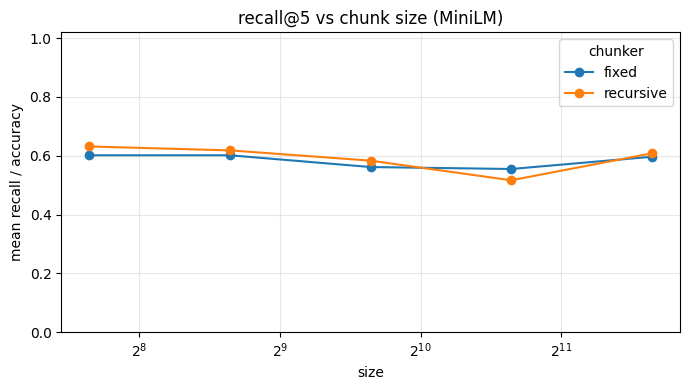

,single_hop,multi_hop,aggregation,temporal,negation,lexical,overall,MRR,total_sec
config,,,,,,,,,
"chunker=fixed, size=200, n_chunks=666",1.0,0.458,0.208,0.722,0.0,0.889,0.602,0.718,0.27
"chunker=fixed, size=400, n_chunks=339",1.0,0.433,0.125,0.889,0.0,0.889,0.602,0.777,0.39
"chunker=fixed, size=800, n_chunks=176",1.0,0.400,0.125,0.556,0.0,1.000,0.562,0.667,0.43
"chunker=fixed, size=1600, n_chunks=97",1.0,0.400,0.125,0.667,0.0,0.833,0.555,0.647,0.28
"chunker=fixed, size=3200, n_chunks=54",1.0,0.450,0.250,0.722,0.0,0.833,0.597,0.737,0.37
"chunker=recursive, size=200, n_chunks=928",1.0,0.458,0.292,0.889,0.0,0.889,0.632,0.700,0.35
"chunker=recursive, size=400, n_chunks=440",1.0,0.425,0.292,0.889,0.0,0.889,0.618,0.727,0.34
"chunker=recursive, size=800, n_chunks=204",0.8,0.425,0.333,0.722,1.0,0.722,0.583,0.770,0.56
"chunker=recursive, size=1600, n_chunks=99",0.8,0.425,0.167,0.556,0.0,0.833,0.517,0.617,0.66


In [10]:
SIZES = [200, 400, 800, 1600, 3200]
for cname, fn in [("fixed", fixed_chunker), ("recursive", recursive_chunker)]:
    for size in SIZES:
        chunks = make_chunks(docs, fn, size, size // 10)
        idx = DenseIndex(chunks, minilm)
        H.eval_retrieval("A-chunking", {"chunker": cname, "size": size, "n_chunks": len(chunks)}, idx.search, k=5)
H.plot_sweep("A-chunking", x="size", series="chunker", logx=True, title="recall@5 vs chunk size (MiniLM)")
H.table("A-chunking")

**A.4 Same sweep, equal context budget.** With k = 5 fixed, a 3200-character setting hands the LLM
16× more text than a 200-character one — not a fair fight. Here k = ⌈4000 / size⌉ so every setting
retrieves about 4,000 characters.

[A-budget] chunker=fixed, size=200, k=20  k=20  recall@20=0.747  MRR=0.724  (0.58s)
   single_ho=1.00  multi_hop=0.54  aggregati=0.58  temporal=0.83  lexical=1.00
[A-budget] chunker=fixed, size=400, k=10  k=10  recall@10=0.635  MRR=0.781  (0.32s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.21  temporal=0.89  lexical=1.00
[A-budget] chunker=fixed, size=800, k=5  k=5  recall@5=0.562  MRR=0.667  (0.33s)
   single_ho=1.00  multi_hop=0.40  aggregati=0.12  temporal=0.56  lexical=1.00
[A-budget] chunker=fixed, size=1600, k=3  k=3  recall@3=0.502  MRR=0.633  (0.56s)
   single_ho=1.00  multi_hop=0.40  aggregati=0.12  temporal=0.39  lexical=0.67
[A-budget] chunker=fixed, size=3200, k=2  k=2  recall@2=0.385  MRR=0.660  (0.57s)
   single_ho=0.60  multi_hop=0.38  aggregati=0.12  temporal=0.28  lexical=0.56
[A-budget] chunker=recursive, size=200, k=20  k=20  recall@20=0.755  MRR=0.706  (0.36s)
   single_ho=1.00  multi_hop=0.56  aggregati=0.54  temporal=0.89  lexical=1.00
[A-budget] chunker=recurs

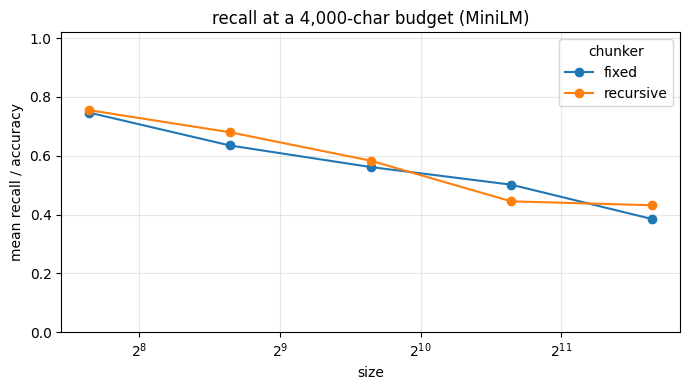

MiniLM max_seq_length = 256 word-pieces


In [11]:
import math
for cname, fn in [("fixed", fixed_chunker), ("recursive", recursive_chunker)]:
    for size in SIZES:
        chunks = make_chunks(docs, fn, size, size // 10)
        k = max(1, math.ceil(4000 / size))
        H.eval_retrieval("A-budget", {"chunker": cname, "size": size, "k": k}, DenseIndex(chunks, minilm).search, k=k)
H.plot_sweep("A-budget", x="size", series="chunker", logx=True, title="recall at a 4,000-char budget (MiniLM)")
print("MiniLM max_seq_length =", minilm.max_seq_length, "word-pieces")

✍️ **Questions A-2 … A-5** (answer in your report, with the plots):

* **A-2** Which chunker and size win at k = 5? At the 4,000-char budget? Why do the two views disagree?
* **A-3** `minilm.max_seq_length` is printed above. Roughly how many characters is that? What happens to
  the *rest* of a 1600- or 3200-character chunk when it is embedded? (Lecture 4-1, "The Truncation Trap".)
  Point to the evidence in your plot.
* **A-4** Look at the `multi_hop` column of `H.table("A-chunking")`. Does *any* chunk size fix multi-hop?
  Use `H.rows("A-chunking", "recursive, size=800")` to find one multi-hop question and list which gold
  documents were missed.
* **A-5** Pick the configuration you will carry into Parts B–E and justify it in two sentences.

---
## Part B — Keyword (BM25) vs. dense vs. hybrid (≈ 20 min)

Chunking is now fixed at **recursive, 800 characters, overlap 80** (change `BEST_SIZE` if your A-5
choice differs). BM25 is a keyword ranker — no embeddings at all. Its quality depends almost entirely on
the **tokenizer**: how does `"CVE-2026-3117,"` become tokens?

In [12]:
BEST_SIZE = 800
CHUNKS = make_chunks(docs, recursive_chunker, BEST_SIZE, BEST_SIZE // 10)
dense_minilm = DenseIndex(CHUNKS, minilm)
print(len(CHUNKS), "chunks")

204 chunks


#### 🛠️ B.1 Build BM25 with three tokenizers, and a hybrid (RRF) retriever

**Contract** (the checks below depend on these exact names): `whitespace_tok`, `word_tok`, `id_tok`; `BM25Index(chunks, tokenizer).search(q, k)`; `rrf_fuse(lists, k=60)`; `HybridIndex(bm25, dense, depth=50).search(q, k)`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, the variable CHUNKS is a list of dicts with a "text" key, and dense_minilm
has a method search(question, k) -> list[dict]. Using the rank_bm25 package, write:

1. Three tokenizers, each str -> list[str]:
   - whitespace_tok: text.lower().split()   (punctuation stays attached, "cve-2026-3117," is one token)
   - word_tok: re.findall(r"[a-z0-9]+", text.lower())   ("cve-2026-3117" -> "cve","2026","3117")
   - id_tok: keeps identifiers whole: re.findall(r"[a-z0-9]+(?:[-_./:][a-z0-9]+)*", text.lower())
2. class BM25Index(chunks, tokenizer) with search(question, k) -> list[dict] (best first), using BM25Okapi.
3. rrf_fuse(ranked_lists, k=60) -> list[dict]: Reciprocal Rank Fusion of several ranked lists of chunk
   dicts, identifying a chunk by chunk["chunk_id"]; score = sum over lists of 1/(k + rank), rank from 1.
4. class HybridIndex(bm25_index, dense_index, depth=50) with search(question, k) that takes the top
   `depth` from each, fuses them with rrf_fuse, and returns the top k.
Put everything in the empty cell under "B.1" and run it.
```

In [21]:
import re
from rank_bm25 import BM25Okapi

def whitespace_tok(text: str) -> list[str]:
    return text.lower().split()

def word_tok(text: str) -> list[str]:
    return re.findall(r"[a-z0-9]+", text.lower())

def id_tok(text: str) -> list[str]:
    return re.findall(r"[a-z0-9]+(?:[-_./:][a-z0-9]+)*", text.lower())

class BM25Index:
    def __init__(self, chunks: list[dict], tokenizer):
        self.chunks = chunks
        self.tokenizer = tokenizer
        corpus = [tokenizer(chunk["text"]) for chunk in chunks]
        self.bm25 = BM25Okapi(corpus)

    def search(self, question: str, k: int) -> list[dict]:
        tokenized_query = self.tokenizer(question)
        scores = self.bm25.get_scores(tokenized_query)
        best_indices = scores.argsort()[::-1][:k]
        return [self.chunks[idx] for idx in best_indices]

def rrf_fuse(ranked_lists: list[list[dict]], k: int = 60) -> list[dict]:
    rrf_scores = {}
    chunk_by_id = {}

    for rank_list in ranked_lists:
        for rank, chunk in enumerate(rank_list, start=1):
            chunk_id = chunk["chunk_id"]
            if chunk_id not in chunk_by_id:
                chunk_by_id[chunk_id] = chunk
            rrf_scores[chunk_id] = rrf_scores.get(chunk_id, 0.0) + 1.0 / (k + rank)

    sorted_ids = sorted(rrf_scores.keys(), key=lambda cid: rrf_scores[cid], reverse=True)
    return [chunk_by_id[cid] for cid in sorted_ids]

class HybridIndex:
    def __init__(self, bm25_index: BM25Index, dense_index, depth: int = 50):
        self.bm25_index = bm25_index
        self.dense_index = dense_index
        self.depth = depth

    def search(self, question: str, k: int) -> list[dict]:
        bm25_results = self.bm25_index.search(question, self.depth)
        dense_results = self.dense_index.search(question, self.depth)
        fused = rrf_fuse([bm25_results, dense_results])
        return fused[:k]

In [14]:
# B.1 check
for t in (whitespace_tok, word_tok, id_tok):
    print(t("Patch CVE-2026-3117, then re-scan VAN-SRV-VPN01."))
H.check_retriever(BM25Index(CHUNKS, id_tok).search, "BM25(id_tok)")
H.check_retriever(HybridIndex(BM25Index(CHUNKS, id_tok), dense_minilm).search, "hybrid");

['patch', 'cve-2026-3117,', 'then', 're-scan', 'van-srv-vpn01.']
['patch', 'cve', '2026', '3117', 'then', 're', 'scan', 'van', 'srv', 'vpn01']
['patch', 'cve-2026-3117', 'then', 're-scan', 'van-srv-vpn01']
  BM25(id_tok): returned 5 items -> docs ['asset-inventory-v1', 'asset-inventory-v2', 'inc-2026-041', 'pir-inc-2026-041']
PASS
  hybrid: returned 5 items -> docs ['asset-inventory-v1', 'inc-2026-041', 'inc-2026-045', 'asset-inventory-v2']
PASS


**B.2 Measure** (provided, ≈ 1 min).

[B-methods@5] method=BM25 whitespace-tok  k=5  recall@5=0.560  MRR=0.557  (0.02s)
   single_ho=0.80  multi_hop=0.41  aggregati=0.25  temporal=0.72  lexical=1.00
[B-methods@5] method=BM25 word-tok  k=5  recall@5=0.655  MRR=0.763  (0.02s)
   single_ho=1.00  multi_hop=0.48  aggregati=0.29  temporal=0.89  lexical=1.00
[B-methods@5] method=BM25 id-tok  k=5  recall@5=0.643  MRR=0.837  (0.02s)
   single_ho=1.00  multi_hop=0.48  aggregati=0.25  temporal=0.83  lexical=1.00
[B-methods@5] method=dense MiniLM  k=5  recall@5=0.583  MRR=0.770  (0.19s)
   single_ho=0.80  multi_hop=0.42  aggregati=0.33  temporal=0.72  lexical=0.72
[B-methods@5] method=hybrid RRF (BM25 id + MiniLM)  k=5  recall@5=0.622  MRR=0.830  (0.2s)
   single_ho=1.00  multi_hop=0.45  aggregati=0.29  temporal=0.72  lexical=1.00
[B-methods@10] method=BM25 whitespace-tok  k=10  recall@10=0.675  MRR=0.563  (0.02s)
   single_ho=1.00  multi_hop=0.53  aggregati=0.46  temporal=0.72  lexical=1.00
[B-methods@10] method=BM25 word-tok  k=10  

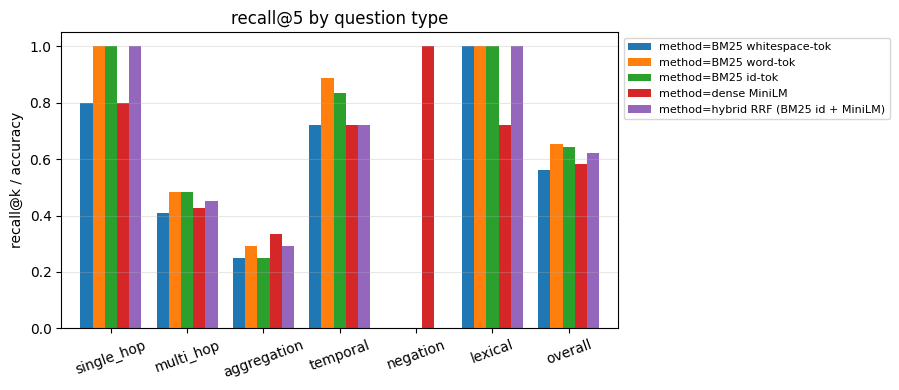

,single_hop,multi_hop,aggregation,temporal,negation,lexical,overall,MRR,total_sec
config,,,,,,,,,
method=BM25 whitespace-tok,0.8,0.408,0.250,0.722,0.0,1.000,0.560,0.557,0.02
method=BM25 word-tok,1.0,0.483,0.292,0.889,0.0,1.000,0.655,0.763,0.02
method=BM25 id-tok,1.0,0.483,0.250,0.833,0.0,1.000,0.643,0.837,0.02
method=dense MiniLM,0.8,0.425,0.333,0.722,1.0,0.722,0.583,0.770,0.19
method=hybrid RRF (BM25 id + MiniLM),1.0,0.450,0.292,0.722,0.0,1.000,0.622,0.830,0.20


,single_hop,multi_hop,aggregation,temporal,negation,lexical,overall,MRR,total_sec
config,,,,,,,,,
method=BM25 whitespace-tok,1.0,0.533,0.458,0.722,0.0,1.0,0.675,0.563,0.02
method=BM25 word-tok,1.0,0.508,0.542,0.889,0.0,1.0,0.695,0.763,0.02
method=BM25 id-tok,1.0,0.558,0.583,1.000,0.0,1.0,0.733,0.837,0.02
method=dense MiniLM,0.8,0.558,0.458,0.889,1.0,1.0,0.705,0.778,0.17
method=hybrid RRF (BM25 id + MiniLM),1.0,0.558,0.583,0.889,0.0,1.0,0.720,0.830,0.21


In [15]:
bm25 = {name: BM25Index(CHUNKS, t) for name, t in
        [("whitespace", whitespace_tok), ("word", word_tok), ("id", id_tok)]}
RETRIEVERS_B = {
    "BM25 whitespace-tok": bm25["whitespace"].search,
    "BM25 word-tok": bm25["word"].search,
    "BM25 id-tok": bm25["id"].search,
    "dense MiniLM": dense_minilm.search,
    "hybrid RRF (BM25 id + MiniLM)": HybridIndex(bm25["id"], dense_minilm).search,
}
for k in (5, 10):
    for name, fn in RETRIEVERS_B.items():
        H.eval_retrieval(f"B-methods@{k}", {"method": name}, fn, k=k)
H.plot_bars("B-methods@5", title="recall@5 by question type")
display(H.table("B-methods@5")); display(H.table("B-methods@10"))

In [16]:
# Inspect the lexical trap: CVE-2026-3117 vs CVE-2026-3171
for q in [q for q in QUESTIONS if q["type"] == "lexical"]:
    print(f"\n{q['id']}: {q['question']}\n  gold: {q['gold_doc_ids']}")
    for name in ["BM25 id-tok", "dense MiniLM"]:
        print(f"  {name:12s} -> {H.doc_ids_of(RETRIEVERS_B[name](q['question'], 5))}")


LEX-01: Which file has SHA-256 3b1f7c9a4e0d2a6b8f5c1d3e7a9b0c2d4e6f8a1b3c5d7e9f0a2b4c6d8e0f1a35?
  gold: ['malware-analysis-lorenzo-loader', 'ti-infrastructure', 'edr-alert-export-20260224']
  BM25 id-tok  -> ['malware-analysis-lorenzo-loader', 'edr-alert-export-20260224-reissue', 'edr-alert-export-20260224', 'inc-2026-043', 'ti-infrastructure']
  dense MiniLM -> ['edr-alert-export-20260224', 'malware-analysis-lorenzo-loader', 'edr-alert-export-20260224-reissue', 'inc-2026-048']

LEX-02: Which product and version range are affected by CVE-2026-3171?
  gold: ['advisory-kestrel-sa-2026-007', 'cve-2026-3171-writeup']
  BM25 id-tok  -> ['advisory-kestrel-sa-2026-007', 'cve-2026-3171-writeup', 'advisory-aperture-sa-2026-014']
  dense MiniLM -> ['cve-2026-3171-writeup', 'cve-2026-3117-writeup', 'advisory-aperture-sa-2026-014', 'asset-inventory-v2']

LEX-03: What is error code KES-5521, and what action did it trigger?
  gold: ['hris-error-log-20260307']
  BM25 id-tok  -> ['hris-error-log-202

✍️ **Questions B-1 … B-4**

* **B-1** Rank the five retrievers by overall recall@5. Did BM25 beat the dense retriever anywhere? Where?
* **B-2** Explain, using the tokenizer printout, why the three BM25 variants differ on `lexical` questions.
  What does this tell you about using *"keyword search"* on logs and IOCs?
* **B-3** For the lexical questions printed above, explain what the dense model "sees" in `CVE-2026-3117`
  vs `CVE-2026-3171` (hint: word-pieces and averaging, lecture 4-1 "Chunk into Vector").
* **B-4** Hybrid search is supposed to be "the best of both worlds". Is it, on every question type? Going
  from k = 5 to k = 10, which type gains most — and which does not move at all? Why?

---
## Part C — Embedding models (≈ 20 min)

Same chunks (recursive, `BEST_SIZE`), same dense retriever class; only the embedding model changes.
Some models need **prefixes**: bge wants an instruction on the query; nomic wants `search_query:` /
`search_document:`. Forgetting a prefix is one of the most common silent RAG bugs.

| model | dim | max input | note |
|---|---|---|---|
| sentence-transformers/all-MiniLM-L6-v2 | 384 | 256 word-pieces | small, fast, the classic default |
| BAAI/bge-base-en-v1.5 | 768 | 512 | query instruction prefix |
| nomic-ai/nomic-embed-text-v1.5 | 768 | 8192 | long context, task prefixes |
| basel/ATTACK-BERT | 768 | 512 | tuned on MITRE ATT&CK text (security domain) |

In [22]:
EMBEDDERS = {
    "MiniLM-L6":   dict(name="sentence-transformers/all-MiniLM-L6-v2"),
    "bge-base":    dict(name="BAAI/bge-base-en-v1.5",
                        qp="Represent this sentence for searching relevant passages: "),
    "nomic-v1.5":  dict(name="nomic-ai/nomic-embed-text-v1.5", qp="search_query: ",
                        dp="search_document: ", trust_remote_code=True),
    "ATTACK-BERT": dict(name="basel/ATTACK-BERT"),
}
MODELS = {}
for key, spec in EMBEDDERS.items():
    m = SentenceTransformer(spec["name"], device="cuda", trust_remote_code=spec.get("trust_remote_code", False))
    if key == "nomic-v1.5":
        m.max_seq_length = 2048
    MODELS[key] = m
    print(f"{key:12s} dim={m.get_sentence_embedding_dimension()}  max_seq_length={m.max_seq_length}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_552/874506164.py:39: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"{key:12s} dim={m.get_sentence_embedding_dimension()}  max_seq_length={m.max_seq_length}")


MiniLM-L6    dim=384  max_seq_length=256


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_552/874506164.py:39: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"{key:12s} dim={m.get_sentence_embedding_dimension()}  max_seq_length={m.max_seq_length}")


...

/tmp/ipykernel_552/874506164.py:39: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"{key:12s} dim={m.get_sentence_embedding_dimension()}  max_seq_length={m.max_seq_length}")


nomic-v1.5   dim=768  max_seq_length=2048


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ATTACK-BERT  dim=768  max_seq_length=384


/tmp/ipykernel_552/874506164.py:39: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"{key:12s} dim={m.get_sentence_embedding_dimension()}  max_seq_length={m.max_seq_length}")


[C-embeddings] model=MiniLM-L6, size=800  k=5  recall@5=0.583  MRR=0.770  (0.18s)
   single_ho=0.80  multi_hop=0.42  aggregati=0.33  temporal=0.72  lexical=0.72
[C-embeddings] model=bge-base, size=800  k=5  recall@5=0.647  MRR=0.847  (0.43s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.42  temporal=0.89  lexical=0.89
[C-embeddings] model=nomic-v1.5, size=800  k=5  recall@5=0.638  MRR=0.833  (0.43s)
   single_ho=1.00  multi_hop=0.45  aggregati=0.38  temporal=0.89  lexical=0.89
[C-embeddings] model=ATTACK-BERT, size=800  k=5  recall@5=0.485  MRR=0.660  (0.33s)
   single_ho=0.80  multi_hop=0.38  aggregati=0.29  temporal=0.28  lexical=0.89
[C-embeddings] model=MiniLM-L6, size=3200  k=5  recall@5=0.608  MRR=0.750  (0.19s)
   single_ho=1.00  multi_hop=0.47  aggregati=0.38  temporal=0.61  lexical=0.83
[C-embeddings] model=bge-base, size=3200  k=5  recall@5=0.578  MRR=0.728  (0.43s)
   single_ho=0.80  multi_hop=0.45  aggregati=0.54  temporal=0.56  lexical=0.89
[C-embeddings] model=nomic-v1.5

,model,size,chunks,encode_sec,dim,index_MB
0,MiniLM-L6,800,204,0.60,384,0.31
1,bge-base,800,204,3.41,768,0.63
2,nomic-v1.5,800,204,4.88,768,0.63
3,ATTACK-BERT,800,204,4.06,768,0.63
4,MiniLM-L6,3200,54,0.18,384,0.08
5,bge-base,3200,54,1.76,768,0.17
6,nomic-v1.5,3200,54,5.86,768,0.17
7,ATTACK-BERT,3200,54,1.59,768,0.17


,single_hop,multi_hop,aggregation,temporal,negation,lexical,overall,MRR,total_sec
config,,,,,,,,,
"model=MiniLM-L6, size=800",0.8,0.425,0.333,0.722,1.0,0.722,0.583,0.770,0.18
"model=bge-base, size=800",1.0,0.458,0.417,0.889,0.0,0.889,0.647,0.847,0.43
"model=nomic-v1.5, size=800",1.0,0.450,0.375,0.889,0.0,0.889,0.638,0.833,0.43
"model=ATTACK-BERT, size=800",0.8,0.375,0.292,0.278,0.0,0.889,0.485,0.660,0.33
"model=MiniLM-L6, size=3200",1.0,0.475,0.375,0.611,0.0,0.833,0.608,0.750,0.19
"model=bge-base, size=3200",0.8,0.450,0.542,0.556,0.0,0.889,0.578,0.728,0.43
"model=nomic-v1.5, size=3200",0.8,0.450,0.333,0.722,0.0,0.889,0.573,0.720,0.45
"model=ATTACK-BERT, size=3200",0.8,0.475,0.208,0.556,0.0,0.833,0.542,0.703,0.35


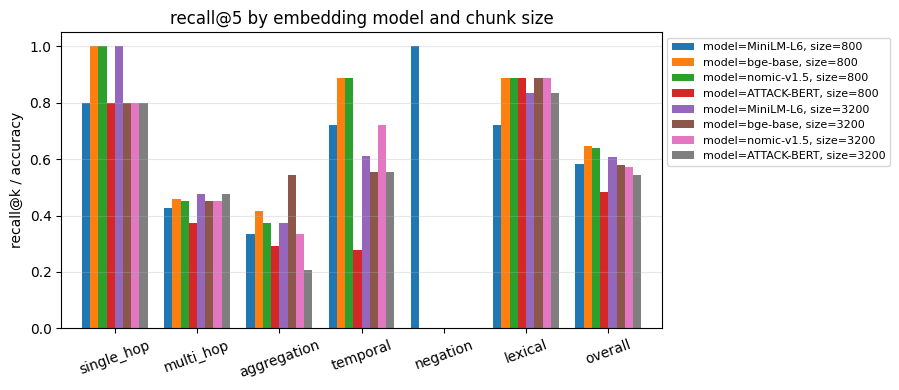

In [23]:
speed = []
for size in (BEST_SIZE, 3200):
    chunks = make_chunks(docs, recursive_chunker, size, size // 10)
    for key, spec in EMBEDDERS.items():
        idx = DenseIndex(chunks, MODELS[key], doc_prefix=spec.get("dp", ""), query_prefix=spec.get("qp", ""))
        H.eval_retrieval("C-embeddings", {"model": key, "size": size}, idx.search, k=5)
        speed.append({"model": key, "size": size, "chunks": len(chunks), "encode_sec": round(idx.encode_sec, 2),
                      "dim": idx.E.shape[1], "index_MB": round(idx.E.nbytes / 1e6, 2)})
display(pd.DataFrame(speed))
display(H.table("C-embeddings"))
H.plot_bars("C-embeddings", title="recall@5 by embedding model and chunk size")

In [24]:
# Prefix bug demo: bge and nomic WITHOUT their prefixes
for key in ("bge-base", "nomic-v1.5"):
    idx = DenseIndex(CHUNKS, MODELS[key])            # no doc_prefix, no query_prefix
    H.eval_retrieval("C-prefix", {"model": key, "prefixes": "none"}, idx.search, k=5)
    spec = EMBEDDERS[key]
    idx = DenseIndex(CHUNKS, MODELS[key], spec.get("dp", ""), spec.get("qp", ""))
    H.eval_retrieval("C-prefix", {"model": key, "prefixes": "correct"}, idx.search, k=5)

[C-prefix] model=bge-base, prefixes=none  k=5  recall@5=0.657  MRR=0.807  (0.45s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.50  temporal=0.89  lexical=0.89
[C-prefix] model=bge-base, prefixes=correct  k=5  recall@5=0.647  MRR=0.847  (0.29s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.42  temporal=0.89  lexical=0.89
[C-prefix] model=nomic-v1.5, prefixes=none  k=5  recall@5=0.673  MRR=0.830  (0.41s)
   single_ho=1.00  multi_hop=0.47  aggregati=0.25  temporal=0.89  lexical=0.89
[C-prefix] model=nomic-v1.5, prefixes=correct  k=5  recall@5=0.638  MRR=0.833  (0.41s)
   single_ho=1.00  multi_hop=0.45  aggregati=0.38  temporal=0.89  lexical=0.89


✍️ **Questions C-1 … C-4**

* **C-1** Fill the table *model · dim · encode time · recall@5 (800) · recall@5 (3200)*. Which model wins at 800? At 3200?
* **C-2** nomic reads 2,048+ word-pieces; MiniLM reads 256. Does the 3200-character result confirm or
  refute your truncation explanation from A-3?
* **C-3** Did the security-domain model (ATTACK-BERT) beat the general models on this *security* corpus?
  Find one question where it wins or loses and explain why (think: what was it trained to put close together?).
* **C-4** What did leaving out the prefixes do to recall@5 and to MRR? Is that what the model cards predict? Why might a 35-document corpus hide (or even reverse) the effect, and how would you test it properly?

---
## Part D — Vector databases, and TurboQuant vector compression (≈ 25 min)

So far the "vector database" was a numpy matrix and a dot product (exact search). Now put the **same**
bge-base vectors into two real stores through the two orchestrators from lecture 5-2, and then
compress them with **TurboQuant**.

* **D.1 ChromaDB through LlamaIndex** — local, in-process, open source.
* **D.2 Pinecone through LangChain** — managed cloud service (free *Starter* plan).
* **D.3 TurboQuant** (Google Research, arXiv 2504.19874) applied to the *vectors*: random rotation +
  per-coordinate scalar quantization to 2–4 bits, via the `turbovec` package.

In [25]:
BGE = MODELS["bge-base"]
BGE_QP = EMBEDDERS["bge-base"]["qp"]
exact_bge = DenseIndex(CHUNKS, BGE, query_prefix=BGE_QP)         # the exact-search reference
H.eval_retrieval("D-stores", {"store": "numpy exact (reference)"}, exact_bge.search, k=5);

[D-stores] store=numpy exact (reference)  k=5  recall@5=0.647  MRR=0.847  (0.29s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.42  temporal=0.89  lexical=0.89


#### 🛠️ D.1 ChromaDB through LlamaIndex

**Contract** (the checks below depend on these exact names): `chroma_search(question, k)` and `chroma_search_current(question, k)`; `chroma_index`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, CHUNKS is a list of dicts with keys "chunk_id", "doc_id", "text", "title",
"status", "date". Using LlamaIndex (llama_index.core) with the ChromaVectorStore
(llama_index.vector_stores.chroma) and a persistent chromadb client at /content/chroma_db:
- set Settings.llm = None (we only retrieve here, no OpenAI key exists)
- embed with llama_index.embeddings.huggingface.HuggingFaceEmbedding(model_name="BAAI/bge-base-en-v1.5",
  query_instruction=BGE_QP, text_instruction="", normalize=True)
- create the collection "vandelay_bge" with metadata {"hnsw:space": "cosine"} (delete it first if it exists)
- build TextNode objects from CHUNKS (id_ = chunk_id, text = text, metadata = doc_id, title, status, date),
  and a VectorStoreIndex over them
- write chroma_search(question, k) -> list of NodeWithScore using index.as_retriever(similarity_top_k=k)
- write chroma_search_current(question, k) that does the same but with a MetadataFilters filter
  status == "current"
Put it in the empty cell under "D.1" and run it.
```

In [27]:
H.check_retriever(chroma_search, "Chroma")
H.eval_retrieval("D-stores", {"store": "Chroma via LlamaIndex"}, chroma_search, k=5)
H.eval_retrieval("D-stores", {"store": "Chroma, filter status=current"}, chroma_search_current, k=5);

  Chroma: returned 5 items -> docs ['asset-inventory-v1', 'asset-inventory-v2', 'inc-2026-043']
PASS
[D-stores] store=Chroma via LlamaIndex  k=5  recall@5=0.570  MRR=0.803  (0.94s)
   single_ho=1.00  multi_hop=0.38  aggregati=0.33  temporal=0.78  lexical=0.72
[D-stores] store=Chroma, filter status=current  k=5  recall@5=0.570  MRR=0.843  (0.64s)
   single_ho=1.00  multi_hop=0.38  aggregati=0.33  temporal=0.78  lexical=0.72


**D.2 Pinecone.** One-time setup (≈ 5 min, screenshots in the handout):
1. Sign up at **app.pinecone.io** (free *Starter* plan; no credit card). 2. *API Keys → Create API key* → copy it.
3. In Colab click the 🔑 **Secrets** icon (left bar) → *Add new secret* → name `PINECONE_API_KEY`, paste the
key, switch **Notebook access** on. Never paste a key into a code cell.

#### 🛠️ D.2 Pinecone through LangChain

**Contract** (the checks below depend on these exact names): `pinecone_search(question, k)`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, CHUNKS is a list of dicts with keys "chunk_id", "doc_id", "text", "title",
"status". My Pinecone key is in Colab Secrets as PINECONE_API_KEY (read it with
google.colab.userdata.get and put it in os.environ). Using the pinecone SDK and langchain_pinecone:
- create (if missing) a serverless index named "cs789-a4", dimension 768, metric "cosine",
  ServerlessSpec(cloud="aws", region="us-east-1"), and wait until it is ready
- embeddings: langchain_huggingface.HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5",
  encode_kwargs={"normalize_embeddings": True}, query_encode_kwargs={"normalize_embeddings": True,
  "prompt": BGE_QP})
- a PineconeVectorStore on that index with namespace "bge-800"; delete everything in the namespace
  first (ignore the error if it does not exist yet), then add_texts with ids = chunk_id and
  metadata doc_id, title, status
- wait until index.describe_index_stats() shows all vectors in the namespace (Pinecone is eventually consistent)
- write pinecone_search(question, k) -> list of LangChain Documents via similarity_search
Put it in the empty cell under "D.2" and run it.
```

In [31]:
if "pinecone_search" in globals():
    H.check_retriever(pinecone_search, "Pinecone")
    H.eval_retrieval("D-stores", {"store": "Pinecone via LangChain"}, pinecone_search, k=5)
display(H.table("D-stores")[["overall", "MRR", "total_sec"]])

  Pinecone: returned 5 items -> docs ['asset-inventory-v1', 'asset-inventory-v2']
PASS
[D-stores] store=Pinecone via LangChain  k=5  recall@5=0.647  MRR=0.847  (3.01s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.42  temporal=0.89  lexical=0.89


,overall,MRR,total_sec
config,,,
store=numpy exact (reference),0.647,0.847,0.29
store=Chroma via LlamaIndex,0.570,0.803,0.94
"store=Chroma, filter status=current",0.570,0.843,0.64
store=Pinecone via LangChain,0.647,0.847,3.01


In [32]:
# Do the stores return the SAME top-5 as exact search?  (agreement = |top5 ∩ exact top5| / 5, chunk level)
def agreement(search_fn, key=lambda r: r["chunk_id"] if isinstance(r, dict) else
              (r.node.node_id if hasattr(r, "node") else getattr(r, "id", None))):
    vals = []
    for q in QUESTIONS:
        ref = {c["chunk_id"] for c in exact_bge.search(q["question"], 5)}
        got = {key(r) for r in search_fn(q["question"], 5)}
        vals.append(len(ref & got) / 5)
    return sum(vals) / len(vals)
print("Chroma   agreement with exact:", round(agreement(chroma_search), 3))
if "pinecone_search" in globals():
    print("Pinecone agreement with exact:", round(agreement(pinecone_search), 3))

Chroma   agreement with exact: 0.546
Pinecone agreement with exact: 0.992


#### 🔎 D.1b Detective work: why does Chroma disagree with exact search?

Same model, same chunks, same query prefix, cosine distance on both sides — yet Chroma's top-5 overlaps
the exact top-5 only about half the time, and its recall@5 is lower. HNSW is approximate, but with a few
hundred vectors it is essentially exact, so that is not it. **Find the real cause before you read on.**

Hints, in order (use as few as you need): (1) what text did LlamaIndex actually *embed* for a node?
(2) `from llama_index.core.schema import MetadataMode` and `node.get_content(metadata_mode=MetadataMode.EMBED)`.
(3) look up `excluded_embed_metadata_keys`.

In [33]:
# Look at what LlamaIndex sent to the embedding model for one node (compare with CHUNKS[0]["text"])
from llama_index.core.schema import MetadataMode
print(repr(nodes[0].get_content(metadata_mode=MetadataMode.EMBED)[:300]))

'doc_id: access-review-q1\ntitle: Q1 2026 Privileged Access Review\nstatus: current\ndate: 2026-02-20\n\n# Q1 2026 Privileged Access Review\n\nReviewer: Rachel Ocampo, Director of IT Operations. Scope: every directory group that\ngrants access to a system classified Confidential or above.\n\n## Entitlements by'


#### 🛠️ D.1b Fix the Chroma index

**Contract** (the checks below depend on these exact names): `chroma_search_textonly(question, k)`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, `nodes` is the list of LlamaIndex TextNode objects I indexed into Chroma, with
metadata keys doc_id, title, status, date. LlamaIndex prepends the metadata to the text it embeds.
Build a second Chroma collection "vandelay_bge_textonly" (same chroma_client, same li_embed, cosine) from
copies of the nodes where every metadata key is listed in excluded_embed_metadata_keys (and in
excluded_llm_metadata_keys), so only the chunk text is embedded but the metadata is still stored for
filtering. Define chroma_search_textonly(question, k) like chroma_search. Do not change the old index.
Put it in the empty cell under "D.1b" and run it, then run the cell below it.
```

In [35]:
print("Chroma (text only) agreement with exact:", round(agreement(chroma_search_textonly), 3))
H.eval_retrieval("D-stores", {"store": "Chroma via LlamaIndex, text only"}, chroma_search_textonly, k=5);

Chroma (text only) agreement with exact: 0.992
[D-stores] store=Chroma via LlamaIndex, text only  k=5  recall@5=0.647  MRR=0.847  (0.57s)
   single_ho=1.00  multi_hop=0.46  aggregati=0.42  temporal=0.89  lexical=0.89


#### 🛠️ D.3 TurboQuant-compressed vector index

**Contract** (the checks below depend on these exact names): `TQIndex(E, chunks, model, query_prefix, bits)` with `.search(q, k)` and `.nbytes`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook, exact_bge.E is a float32 numpy matrix of normalized bge-base chunk vectors
(one row per chunk in CHUNKS), exact_bge.model is the SentenceTransformer and BGE_QP the query prefix.
Using the turbovec package (from turbovec import TurboQuantIndex; TurboQuantIndex(dim=..., bit_width=b);
.add(matrix); .search(query_matrix, k) returns (scores, indices); .to_bytes() gives the serialized index):
write a class TQIndex(E, chunks, model, query_prefix, bits) with
- search(question, k) -> list of chunk dicts (best first)
- nbytes: the size in bytes of the serialized TurboQuant index
Put it in the empty cell under "D.3" and run it.
```

In [37]:
N, dim = exact_bge.E.shape
def marginal_bytes(bits, n=2048):
    # index 2n vs n random unit vectors: the difference / n is what one more vector costs
    from turbovec import TurboQuantIndex
    R = np.random.default_rng(0).standard_normal((2 * n, dim)).astype("float32")
    R /= np.linalg.norm(R, axis=1, keepdims=True)
    size = []
    for m in (n, 2 * n):
        ix = TurboQuantIndex(dim=dim, bit_width=bits); ix.add(R[:m]); size.append(len(ix.to_bytes()))
    return (size[1] - size[0]) / n
tq_rows = [{"index": "float32 exact", "bits/dim": 32, "file bytes": exact_bge.E.nbytes, "bytes/vector": 4 * dim,
            "recall@5": H.table("D-stores").loc["store=numpy exact (reference)", "overall"], "agreement": 1.0}]
for bits in (4, 3, 2):
    tq = TQIndex(exact_bge.E, CHUNKS, BGE, BGE_QP, bits)
    per_vec = marginal_bytes(bits)                              # cost of one more vector
    df = H.eval_retrieval("D-turboquant", {"bits": bits}, tq.search, k=5, verbose=False)
    tq_rows.append({"index": f"TurboQuant {bits}-bit", "bits/dim": bits, "file bytes": tq.nbytes,
                    "bytes/vector": round(per_vec, 1),
                    "recall@5": round(df.recall.mean(), 3), "agreement": round(agreement(tq.search), 3)})
tq_df = pd.DataFrame(tq_rows)
tq_df["compression per vector"] = (4 * dim / tq_df["bytes/vector"]).round(1)
tq_df["fixed overhead (bytes)"] = (tq_df["file bytes"] - N * tq_df["bytes/vector"]).round(0)
display(tq_df)

,index,bits/dim,file bytes,bytes/vector,recall@5,agreement,compression per vector,fixed overhead (bytes)
0,float32 exact,32,626688,3072.0,0.647,1.000,1.0,0.0
1,TurboQuant 4-bit,4,913892,388.0,0.642,0.962,7.9,834740.0
2,TurboQuant 3-bit,3,913828,388.0,0.642,0.962,7.9,834676.0
3,TurboQuant 2-bit,2,471812,196.0,0.652,0.869,15.7,431828.0


✍️ **Questions D-1 … D-4**

* **D-1b** What did LlamaIndex embed, and what did fixing it do to agreement and recall@5? Is putting the
  title into the embedded text *always* bad? Give one question type where it could help.
* **D-1** After the fix, did Chroma or Pinecone change recall@5 compared with the numpy exact search? What *did* change
  (latency, setup effort, where the data lives)? Fill: *store · recall@5 · agreement · seconds for 25 queries*.
* **D-2** The `status == "current"` filter: did it change recall@5 at all? Which metric moved? Look at
  TMP-01 and TMP-03 with `H.rows("D-stores", "filter")`. When would a status filter help, and when would it hide the evidence an analyst needs (think: a temporal question about what changed)?
* **D-3** TurboQuant: the *file* of the 4-bit index is bigger than the float32 matrix — why? (Look at the
  *fixed overhead* column: what does the index store once, whatever the number of vectors?) Why are the
  3-bit and 4-bit indexes the same size in `turbovec` 1.0? Per vector, how many times smaller is each bit width, and what did it cost in recall and in agreement? With only a few hundred
  vectors, would you bother? At 100 million vectors (768-d), how much
  memory does float32 need vs. 4-bit? Show the arithmetic.
* **D-4** Security: lecture 4-2 listed CVE-2026-45829 ("ChromaToast", pre-auth RCE in ChromaDB). Your Chroma
  runs *in-process* here. Name one deployment choice that would have exposed it, and one that limits the damage.

---
## Part E — Answer accuracy, and TurboQuant for the KV cache (≈ 30 min, 15 of it unattended)

Retrieval recall is not answer accuracy. Now an LLM answers all 26 questions — **Qwen3-4B-Instruct-2507**
served by **vLLM** on your GPU (256k-token native context, so the whole corpus fits). Three pipelines:

1. **naive RAG** — fixed chunks, 800 chars, no overlap, MiniLM, top-3 (the "RAG in 50 lines" pipeline)
2. **your best RAG** — your best chunking + retriever from Parts A–D, top-8
3. **full context** — no retrieval: all 35 documents (~32k tokens) in the prompt

Then the KV cache. The whole-corpus prompt is ~32k tokens; its keys and values sit in GPU memory for
every layer. vLLM can store them as bf16 (`auto`), `fp8`, or with **TurboQuant** at 8/4/3 bits.
You will measure capacity (tokens that fit) *and* accuracy.

> ⚠️ Correction to lecture 3-2, slide "TurboQuant Availability": as of September 2026 TurboQuant KV-cache
> types are **not** in upstream llama.cpp (PR closed June 2026) or Ollama (PR closed May 2026); they
> shipped in **vLLM ≥ 0.20** as `--kv-cache-dtype turboquant_*`. That is why this part uses vLLM.

In [39]:
# E.0 Free the GPU for vLLM (embedding models move to the CPU) and wait for the background install
import gc, torch
for m in list(MODELS.values()) + [minilm]:
    m.to("cpu")
gc.collect(); torch.cuda.empty_cache()
if IN_COLAB:
    print("waiting for the vLLM install to finish ...")
    vllm_install.wait()
    !tail -2 /content/vllm_install.log
kv_auto = H.start_vllm("auto")          # first start downloads the model (~8 GB, 1-3 min)
print(H.llm("In one sentence: what is MITRE ATT&CK?"))

waiting for the vLLM install to finish ...
vLLM 0.31.0 installed in /content/vllm-env
complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "uvloop/loop.pyx", line 1515, in uvloop.loop.Loop.run_until_complete
  File "/content/vllm-env/lib/python3.12/site-packages/uvloop/__init__.py", line 48, in wrapper
    return await main
           ^^^^^^^^^^
  File "/content/vllm-env/lib/python3.12/site-packages/vllm/entrypoints/launchers/api_server/entry.py", line 172, in run_server
    await run_server_worker(listen_address, sock, args, **uvicorn_kwargs)
  File "/content/vllm-env/lib/python3.12/site-packages/vllm/entrypoints/launchers/api_server/entry.py", line 185, in run_server_worker
    async with build_async_engine_client(
  File "/usr/lib/python3.12/contextlib.py", line 210, in __aenter__
    return await anext(self.gen)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/vllm-env/lib/python3.12/site-packages/vllm/entrypoints/launchers/api_server/entry.py", line 58, in build_a

RuntimeError: vLLM (chat, kv_cache_dtype=auto) exited while starting -- see the log above

#### 🛠️ E.1 The RAG answer function

**Contract** (the checks below depend on these exact names): `SYSTEM`, `rag_answer(question, search, k)` → `(answer, hits)`, `full_context_answer(question)` → `str`

**🤖 Prompt for your AI assistant** — copy it into Claude in Chrome, Gemini in Chrome or Gemini in Colab, adapt it, and have the assistant write the code into the empty cell below and run it. Keep the prompt you finally used: it goes into your report.

```text
In this Colab notebook there is a helper H.llm(prompt, system=None, max_tokens=400) that returns the
local model's answer as a string. Write:

SYSTEM = a system prompt for a SOC analyst assistant that must answer ONLY from the provided
documents, cite the doc ids it used in [square brackets], keep the answer under 120 words, and say
exactly "I do not know" when the documents do not contain the answer.

rag_answer(question, search, k) -> (answer_text, hits): call search(question, k) (it returns a list of
chunk dicts with "doc_id", "title" and "text"), build a context where every chunk starts with
"[doc_id] title", ask H.llm with SYSTEM, and return (answer, hits).

full_context_answer(question) -> str: the same prompt style but the context is the variable
FULL_CORPUS (a string holding every document) instead of retrieved chunks.
Put it in the empty cell under "E.1" and run it.
```

In [ ]:
# ⬇️ YOUR CODE HERE (written with your AI assistant)
# Contract: SYSTEM, rag_answer(question, search, k) → (answer, hits), full_context_answer(question) → str

In [ ]:
# E.1 check: one question each way
q = QUESTIONS[0]["question"]; print(q)
print("RAG :", rag_answer(q, dense_minilm.search, 5)[0])
print("FULL:", full_context_answer(q))
print("corpus tokens:", H.count_tokens(FULL_CORPUS))

**E.2 Three pipelines, 26 questions each** (provided; ≈ 5 min). Edit `best_search` to *your* best retriever.

In [ ]:
naive_chunks = make_chunks(docs, fixed_chunker, 800, 0)
naive_index = DenseIndex(naive_chunks, minilm)                     # MiniLM now runs on the CPU: fine for queries
best_search = HybridIndex(BM25Index(CHUNKS, id_tok), exact_bge, depth=50).search   # <- your choice from A-D

H.eval_answers("E-answers", {"pipeline": "1 naive RAG (fixed-800, MiniLM, k=3)"},
               lambda q: rag_answer(q, naive_index.search, 3))
H.eval_answers("E-answers", {"pipeline": "2 best RAG (k=8)"}, lambda q: rag_answer(q, best_search, 8))
H.eval_answers("E-answers", {"pipeline": "3 full context (~32k tokens)"}, full_context_answer)
H.plot_bars("E-answers", title="answer accuracy by question type")
display(H.table("E-answers"))

In [ ]:
# Read the answers yourself — the scorer is a substring matcher, not a judge.
view = H.rows("E-answers")[["config", "id", "type", "grade", "coverage", "missing", "answer"]]
view[view.id.isin(["MH-01", "AGG-01", "NEG-01", "LEX-02"])]

**E.3 KV-cache precision sweep** (provided; ≈ 15 min unattended). For each `--kv-cache-dtype` vLLM
restarts, reports how many tokens of KV cache fit in GPU memory, and answers the 26 questions with the
**full-context** pipeline — the case where the KV cache is biggest.

In [ ]:
KV_TYPES = ["auto", "fp8", "turboquant_k8v4", "turboquant_4bit_nc", "turboquant_3bit_nc"]
kv_rows = []
for kv in KV_TYPES:
    try:
        info = H.start_vllm(kv)
    except Exception as e:
        print(f"{kv}: could not start ({e}); skipping"); continue
    df = H.eval_answers("E-kvcache", {"kv_cache_dtype": kv}, full_context_answer)
    kv_rows.append({"kv_cache_dtype": kv, "KV tokens": info["kv_tokens"], "KV GiB": info["kv_gib"],
                    "concurrency @49k": info["max_concurrency"], "accuracy": round(df.correct.mean(), 3),
                    "H": int((df.grade == "H").sum()), "sec / question": round(df.sec.mean(), 2)})
kv_df = pd.DataFrame(kv_rows)
kv_df["capacity vs auto"] = (kv_df["KV tokens"] / kv_df["KV tokens"].iloc[0]).round(2)
display(kv_df)
H.start_vllm("auto");   # leave the default server running

✍️ **Questions E-1 … E-5**

* **E-1** Fill the accuracy table (3 pipelines × 6 question types + overall + H + A). Which pipeline wins
  `multi_hop`? `aggregation`? `negation`? Did retrieval recall from Parts A–C predict answer accuracy?
* **E-2** Read the four answers printed after E.2 for each pipeline. Mark one place where the scorer is
  **wrong** (a correct answer scored W, or a wrong one scored C). What does that say about substring scoring?
* **E-3** If full context wins, why does anyone use RAG? Use numbers: tokens per question, seconds per
  question (the `sec` column), and what happens when the corpus is 35,000 documents instead of 35.
* **E-4** KV cache: how many more tokens fit with fp8 and with TurboQuant 4-bit and 3-bit than with `auto`?
  What happened to accuracy? vLLM's own study (May 2026) concluded *"FP8 remains the best default"* —
  do your numbers agree?
* **E-5** Security angle (lecture 3-2): name one KV-cache attack, and say whether quantizing the cache
  changes that risk.

---
## Part F — Report (write in the handout)

1. **One summary table**: rows = best configuration from each part; columns = recall@5 or accuracy, per type.
2. **Answers** to A-1 … E-5 (short; numbers from *your* run).
3. **AI-assistant log**: which assistant you used; three prompts you actually sent (one that worked
   first time, one that failed, and how you fixed it). Where did the assistant produce wrong code that the
   check cells caught? Where would you **not** have noticed without a check?
4. **Your recommendation**, one paragraph: you are building RAG over your SOC's tickets and logs. Which
   chunker, retriever, embedding model, store and KV-cache precision do you pick, and why?

Then `File → Print → Save as PDF` this notebook (with outputs) and attach it after the handout.

In [ ]:
# Save everything you measured (attach results/results.jsonl if asked)
import shutil; print(open("results/results.jsonl").read()[:300], "...")